In [28]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [29]:
df = pd.read_csv("../data/stud.csv")

In [30]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [31]:
X = df.drop(columns="math_score")
y = df['math_score']

In [32]:
X.columns,y.name

(Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
        'test_preparation_course', 'reading_score', 'writing_score'],
       dtype='object'),
 'math_score')

In [33]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

num_transformer = StandardScaler()
ohe = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',ohe,cat_features),
        ('StandardScaler',num_transformer,num_features),
    ]
)

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [36]:
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    rmse = root_mean_squared_error(true,predicted)
    r2 = r2_score(true,predicted)
    return mse, rmse, r2

In [52]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),
    "RandomForestRegressor": RandomForestRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "XGBRegressor": XGBRegressor(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "SVR": SVR()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_transformed,y_train)
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)
    
    y_train_mse, y_train_rmse,y_train_r2 = evaluate_model(y_train,y_train_pred)
    y_test_mse, y_test_rmse,y_test_r2 = evaluate_model(y_test,y_test_pred)

    results[name] = {
        "train_rmse": y_train_rmse,
        "test_rmse": y_test_rmse,
        "train_r2": y_train_r2,
        "test_r2": y_test_r2
    }


Training LinearRegression...
Training Lasso...
Training Ridge...
Training ElasticNet...
Training RandomForestRegressor...
Training CatBoostRegressor...
Training XGBRegressor...
Training KNeighborsRegressor...
Training SVR...


In [42]:
pd.DataFrame(results).T.sort_values("test_r2",ascending=False)

,train_rmse,test_rmse,train_r2,test_r2
Ridge,5.323321,5.390418,0.874304,0.880592
LinearRegression,5.323051,5.393994,0.874317,0.880433
RandomForestRegressor,2.293746,5.977365,0.976663,0.853172
CatBoostRegressor,3.042664,6.004608,0.958936,0.851831
XGBRegressor,1.007282,6.473307,0.995500,0.827797
Lasso,6.592504,6.517347,0.807223,0.825446
KNeighborsRegressor,5.697442,7.217202,0.856016,0.785944
ElasticNet,7.731218,7.941232,0.734875,0.740842
SVR,6.572065,8.119063,0.808416,0.729105


In [46]:
model = Ridge()
model.fit(X_train_transformed,y_train)
y_pred = model.predict(X_test_transformed)
score = r2_score(y_test,y_pred)
print(f"R2 score: {score}")

R2 score: 0.8805917946912825


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt


Text(0, 0.5, 'Predicted')

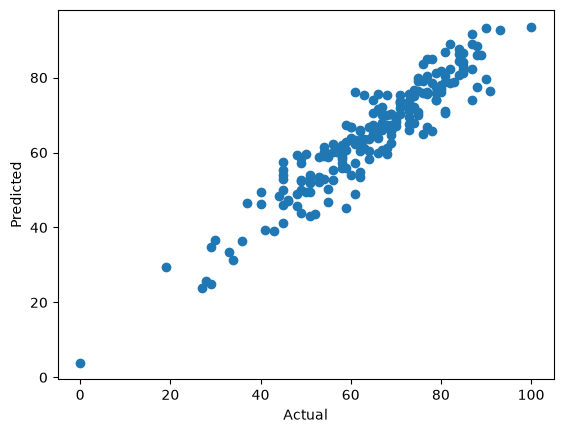

In [48]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

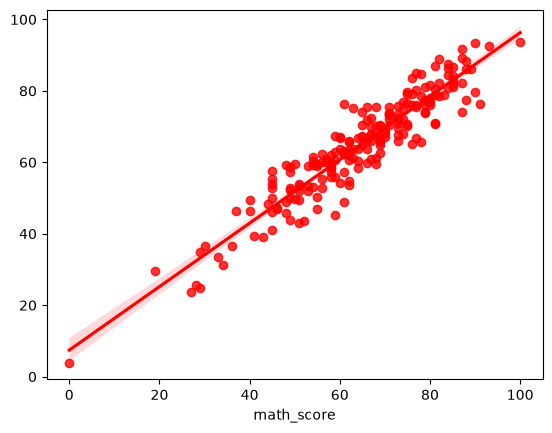

In [51]:
sns.regplot(x=y_test,y=y_pred,color='red')
plt.show()